In [1]:
import pandas as pd
import numpy as np
from numpy import transpose as T
import glob
import os
import cartopy
import cartopy.crs as ccrs
import matplotlib
from matplotlib.lines import Line2D
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.patches as mpatches
import matplotlib.lines as mlines
from matplotlib.ticker import MultipleLocator
from matplotlib.gridspec import GridSpec
import matplotlib.cm as cm
import geopandas as gpd
from scipy.optimize import curve_fit
from netCDF4 import Dataset
import scipy
from scipy import stats
from scipy.ndimage import distance_transform_edt
from datetime import datetime,timedelta
from numpy import genfromtxt as gftxt
import regionmask
from pyproj import Transformer
from datetime import datetime,timedelta
import sys
from pathlib import Path

In [2]:
sys.path.append(str(Path.cwd().parents[1]))
from utils.grid_map_functions import(land_masking, defining_grids)

map_projection = ccrs.NorthPolarStereo()

x_grid_edge_25,y_grid_edge_25,new_x_edge_25,new_y_edge_25 = defining_grids(map_projection,[-180, 180, 90, 65],25000,'edge')
x_grid_centre_25,y_grid_centre_25,new_x_centre_25,new_y_centre_25 = defining_grids(map_projection,[-180, 180, 90, 65],25000,'centre')
land_mask_25 = land_masking(new_x_centre_25,new_y_centre_25,map_projection)

transformer = Transformer.from_crs(map_projection, "EPSG:4326", always_xy=True)
lon0, lat0 = transformer.transform(new_x_centre_25.ravel(), new_y_centre_25.ravel())
lon1 = lon0.reshape(new_x_centre_25.shape)
lat1 = lat0.reshape(new_y_centre_25.shape)

from utils.stats_functions import(absdiff,corr,rmsd)

base_dir = ('/Users/amyswiggs/Desktop/Spring_2026/Arctic_Sea_Surface_Classification/Data/')

In [3]:
lead_clim_means_81_df = pd.read_csv(f'{base_dir}Monthly_Averages/81_Latitude_Lead_Fraction_Averages.csv')
lead_clim_means_df = pd.read_csv(f'{base_dir}Monthly_Averages/Merged_Lead_Fraction_Averages.csv')

lead_clim_means_df['mm'] = lead_clim_means_df['Month'] % 100   

lead_clim_means_df[['CS2 Anom','IS2 Anom']] = (lead_clim_means_df
                                               .groupby('mm')[['CS2','IS2']].transform(lambda x: x - x.mean()))

lead_clim_means_81_df['mm'] = lead_clim_means_81_df['Month'] % 100   

lead_clim_means_81_df[['S3 Anom','CS2 Anom','IS2 Anom']] = (lead_clim_means_81_df
                                                            .groupby('mm')[['S3','CS2','IS2']].transform(lambda x: x - x.mean()))

In [4]:
lead_fraction_81_df = pd.read_csv(f'{base_dir}Monthly_Averages/81_Latitude_Lead_Fraction_Averages.csv')
lead_fraction_df = pd.read_csv(f'{base_dir}Monthly_Averages/Merged_Lead_Fraction_Averages.csv')


lead_fraction_scatter = lead_fraction_df.copy()
lead_fraction_scatter['mm'] = lead_fraction_scatter['Month'] % 100     
lead_fraction_scatter['yyyy']  = lead_fraction_scatter['Month'] // 100   

lead_fraction_81_scatter = lead_fraction_81_df.copy()
lead_fraction_81_scatter['mm'] = lead_fraction_81_scatter['Month'] % 100     
lead_fraction_81_scatter['yyyy']  = lead_fraction_81_scatter['Month'] // 100  

month_names = {1: 'Jan', 2: 'Feb', 3: 'Mar', 4: 'Apr',
               10: 'Oct', 11: 'Nov', 12: 'Dec'}

unique_months = lead_fraction_scatter['mm'].unique()
colours = cm.tab10(np.linspace(0, 1, len(unique_months)))
colour_map = dict(zip(unique_months, colours))


# Including Anomalies

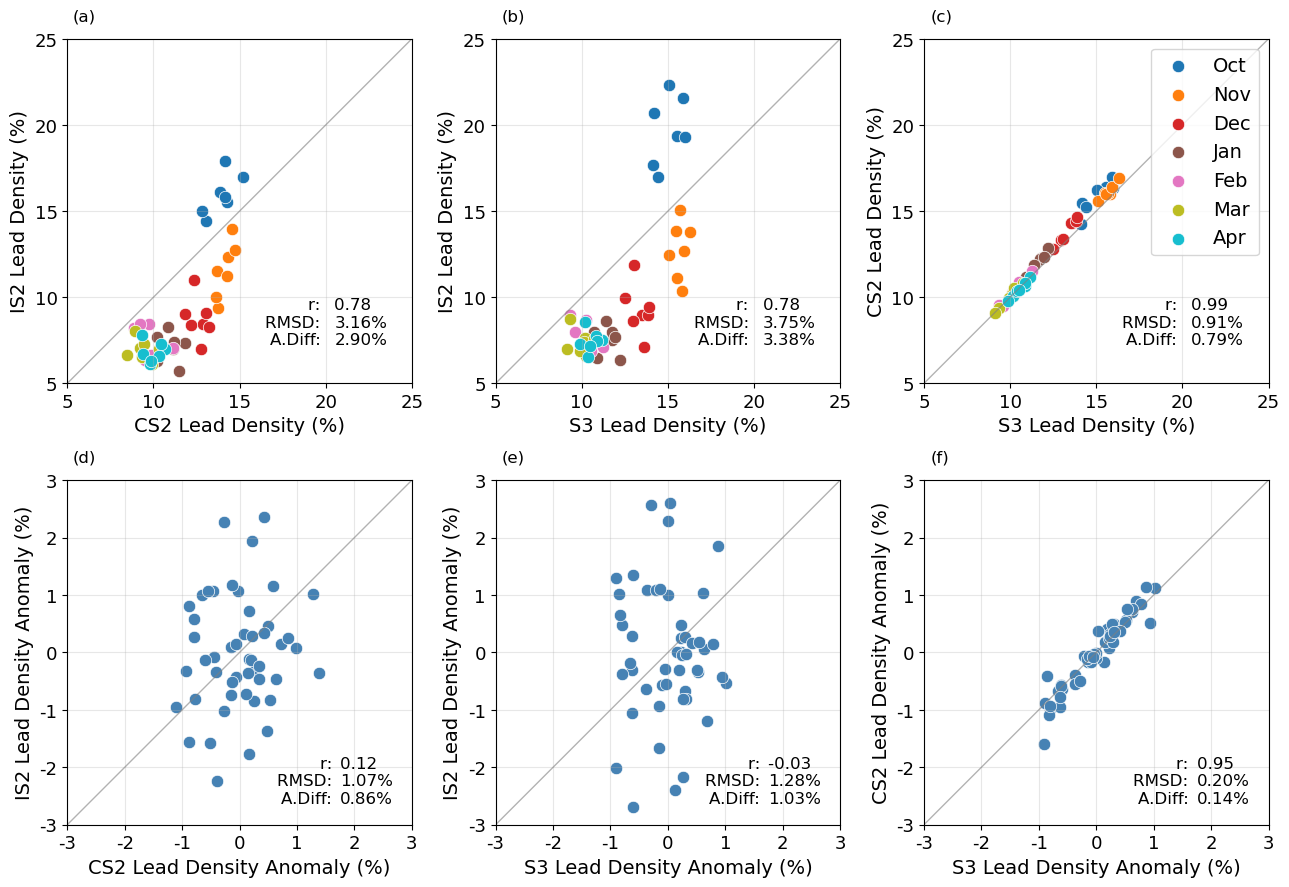

In [5]:
fig, ax = plt.subplots(2,3,figsize=(13,9))

# Monthly Averages
for month in unique_months:
    mask = lead_fraction_scatter['mm'] == month
    subset = lead_fraction_scatter[mask]
    ax[0,0].scatter(subset['CS2'], subset['IS2'],
               color=colour_map[month], label=month_names[month],
               s=80, edgecolors='white', linewidths=0.5)
    
for month in unique_months:
    mask = lead_fraction_81_scatter['mm'] == month
    subset = lead_fraction_81_scatter[mask]    
    ax[0,1].scatter(subset['S3'], subset['IS2'],
               color=colour_map[month], label=month_names[month],
               s=80, edgecolors='white', linewidths=0.5)
    ax[0,2].scatter(subset['S3'], subset['CS2'],
               color=colour_map[month], label=month_names[month],
               s=80, edgecolors='white', linewidths=0.5)

ax[0,0].set_xlabel('CS2 Lead Density (%)', fontsize=14)
ax[0,0].set_ylabel('IS2 Lead Density (%)', fontsize=14)

ax[0,1].set_xlabel('S3 Lead Density (%)', fontsize=14)
ax[0,1].set_ylabel('IS2 Lead Density (%)', fontsize=14)

ax[0,2].set_xlabel('S3 Lead Density (%)', fontsize=14)
ax[0,2].set_ylabel('CS2 Lead Density (%)', fontsize=14)



for col in range(0,3):
    ax[0,col].set_xlim([5,25])
    ax[0,col].set_ylim([5,25])

    ax[0,col].set_xticks([5,10,15,20,25])
    ax[0,col].set_xticklabels([5,10,15,20,25])

    ax[0,col].set_yticks([5,10,15,20,25])
    ax[0,col].set_yticklabels([5,10,15,20,25])

    ax[0,col].xaxis.grid(True, 'major', alpha=0.3)
    ax[0,col].yaxis.grid(True, 'major', alpha=0.3)
    ax[0,col].tick_params(axis='both', which='major', labelsize=13)

    ax[0,col].axline((0, 0), (25, 25), linestyle='-', color='grey', alpha=0.6,linewidth=1)
    
    ax[0,col].set_aspect('equal', adjustable='box') 

ax[0,0].text(20,11,f"\nr: \nRMSD: \nA.Diff: \n",
           fontsize=12,verticalalignment='top',horizontalalignment='right')
ax[0,0].text(20.5,11,f"\n{corr(lead_fraction_scatter['CS2'], lead_fraction_scatter['IS2']):.2f} \n"
           f"{rmsd(lead_fraction_scatter['CS2'], lead_fraction_scatter['IS2']):.2f}%\n"
           f"{absdiff(lead_fraction_scatter['CS2'], lead_fraction_scatter['IS2']):.2f}%",
           fontsize=12,verticalalignment='top',horizontalalignment='left')

ax[0,1].text(20,11,f"\nr: \nRMSD: \nA.Diff: \n",
           fontsize=12,verticalalignment='top',horizontalalignment='right')
ax[0,1].text(20.5,11,f"\n{corr(lead_fraction_scatter['S3'], lead_fraction_scatter['IS2']):.2f} \n"
           f"{rmsd(lead_fraction_scatter['S3'], lead_fraction_scatter['IS2']):.2f}%\n"
           f"{absdiff(lead_fraction_scatter['S3'], lead_fraction_scatter['IS2']):.2f}%",
           fontsize=12,verticalalignment='top',horizontalalignment='left')

ax[0,2].text(20,11,f"\nr: \nRMSD: \nA.Diff: \n",
           fontsize=12,verticalalignment='top',horizontalalignment='right')
ax[0,2].text(20.5,11,f"\n{corr(lead_fraction_scatter['S3'], lead_fraction_scatter['CS2']):.2f} \n"
           f"{rmsd(lead_fraction_scatter['S3'], lead_fraction_scatter['CS2']):.2f}%\n"
           f"{absdiff(lead_fraction_scatter['S3'], lead_fraction_scatter['CS2']):.2f}%",
           fontsize=12,verticalalignment='top',horizontalalignment='left')


ax[0,2].legend(loc='upper right',fontsize=14,frameon=True)


# Anomalies
ax[1,0].scatter(lead_clim_means_df['CS2 Anom'], lead_clim_means_df['IS2 Anom'],
           color='SteelBlue',s=80, edgecolors='white', linewidths=0.5)
ax[1,1].scatter(lead_clim_means_81_df['S3 Anom'], lead_clim_means_81_df['IS2 Anom'],
           color='SteelBlue',s=80, edgecolors='white', linewidths=0.5)
ax[1,2].scatter(lead_clim_means_81_df['S3 Anom'], lead_clim_means_81_df['CS2 Anom'],
           color='SteelBlue',s=80, edgecolors='white', linewidths=0.5)

ax[1,0].set_xlabel('CS2 Lead Density Anomaly (%)', fontsize=14)
ax[1,0].set_ylabel('IS2 Lead Density Anomaly (%)', fontsize=14)

ax[1,1].set_xlabel('S3 Lead Density Anomaly (%)', fontsize=14)
ax[1,1].set_ylabel('IS2 Lead Density Anomaly (%)', fontsize=14)

ax[1,2].set_xlabel('S3 Lead Density Anomaly (%)', fontsize=14)
ax[1,2].set_ylabel('CS2 Lead Density Anomaly (%)', fontsize=14)

for col in range(0,3):
    ax[1,col].set_xlim([-3,3])
    ax[1,col].set_ylim([-3,3])
    
    ax[1,col].set_xticks([-3,-2,-1,0,1,2,3])
    ax[1,col].set_xticklabels([-3,-2,-1,0,1,2,3])

    ax[1,col].set_yticks([-3,-2,-1,0,1,2,3])
    ax[1,col].set_yticklabels([-3,-2,-1,0,1,2,3])

    ax[1,col].xaxis.grid(True, 'major', alpha=0.3)
    ax[1,col].yaxis.grid(True, 'major', alpha=0.3)
    ax[1,col].tick_params(axis='both', which='major', labelsize=13)

    ax[1,col].axline((-3, -3), (3, 3), linestyle='-', color='grey', alpha=0.6,linewidth=1)
    
    ax[1,col].set_aspect('equal', adjustable='box') 

ax[1,0].text(1.7,-1.5,f"\nr: \nRMSD: \nA.Diff: \n",
           fontsize=12,verticalalignment='top',horizontalalignment='right')
ax[1,0].text(1.75,-1.5,f"\n{corr(lead_clim_means_df['CS2 Anom'], lead_clim_means_df['IS2 Anom']):.2f} \n"
           f"{rmsd(lead_clim_means_df['CS2 Anom'], lead_clim_means_df['IS2 Anom']):.2f}%\n"
           f"{absdiff(lead_clim_means_df['CS2 Anom'], lead_clim_means_df['IS2 Anom']):.2f}%",
           fontsize=12,verticalalignment='top',horizontalalignment='left')

ax[1,1].text(1.7,-1.5,f"\nr: \nRMSD: \nA.Diff: \n",
           fontsize=12,verticalalignment='top',horizontalalignment='right')
ax[1,1].text(1.75,-1.5,f"\n{corr(lead_clim_means_81_df['S3 Anom'], lead_clim_means_81_df['IS2 Anom']):.2f} \n"
           f"{rmsd(lead_clim_means_81_df['S3 Anom'], lead_clim_means_81_df['IS2 Anom']):.2f}%\n"
           f"{absdiff(lead_clim_means_81_df['S3 Anom'], lead_clim_means_81_df['IS2 Anom']):.2f}%",
           fontsize=12,verticalalignment='top',horizontalalignment='left')

ax[1,2].text(1.7,-1.5,f"\nr: \nRMSD: \nA.Diff: \n",
           fontsize=12,verticalalignment='top',horizontalalignment='right')
ax[1,2].text(1.75,-1.5,f"\n{corr(lead_clim_means_81_df['S3 Anom'], lead_clim_means_81_df['CS2 Anom']):.2f} \n"
           f"{rmsd(lead_clim_means_81_df['S3 Anom'], lead_clim_means_81_df['CS2 Anom']):.2f}%\n"
           f"{absdiff(lead_clim_means_81_df['S3 Anom'], lead_clim_means_81_df['CS2 Anom']):.2f}%",
           fontsize=12,verticalalignment='top',horizontalalignment='left')


fig.text(0.06,0.98,'(a)',fontsize=12)
fig.text(0.39,0.98,'(b)',fontsize=12)
fig.text(0.72,0.98,'(c)',fontsize=12)

fig.text(0.06,0.49,'(d)',fontsize=12)
fig.text(0.39,0.49,'(e)',fontsize=12)
fig.text(0.72,0.49,'(f)',fontsize=12)

plt.tight_layout()
plt.show()


# Without Anomalies

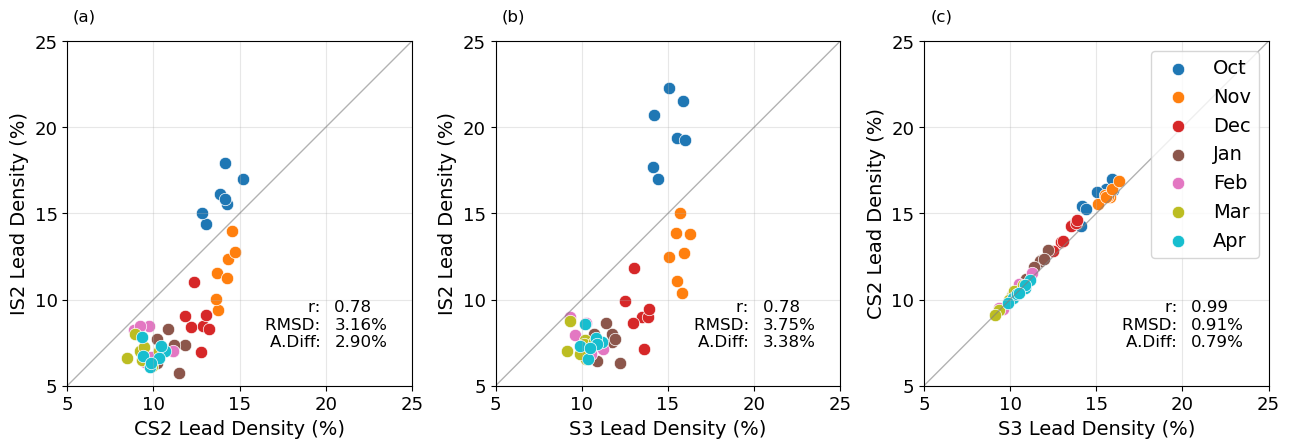

In [17]:
fig, ax = plt.subplots(1,3,figsize=(13,6))

# Monthly Averages
for month in unique_months:
    mask = lead_fraction_scatter['mm'] == month
    subset = lead_fraction_scatter[mask]
    ax[0].scatter(subset['CS2'], subset['IS2'],
               color=colour_map[month], label=month_names[month],
               s=80, edgecolors='white', linewidths=0.5)
    
for month in unique_months:
    mask = lead_fraction_81_scatter['mm'] == month
    subset = lead_fraction_81_scatter[mask]    
    ax[1].scatter(subset['S3'], subset['IS2'],
               color=colour_map[month], label=month_names[month],
               s=80, edgecolors='white', linewidths=0.5)
    ax[2].scatter(subset['S3'], subset['CS2'],
               color=colour_map[month], label=month_names[month],
               s=80, edgecolors='white', linewidths=0.5)

ax[0].set_xlabel('CS2 Lead Density (%)', fontsize=14)
ax[0].set_ylabel('IS2 Lead Density (%)', fontsize=14)

ax[1].set_xlabel('S3 Lead Density (%)', fontsize=14)
ax[1].set_ylabel('IS2 Lead Density (%)', fontsize=14)

ax[2].set_xlabel('S3 Lead Density (%)', fontsize=14)
ax[2].set_ylabel('CS2 Lead Density (%)', fontsize=14)


for col in range(3):
    ax[col].set_xlim([5,25])
    ax[col].set_ylim([5,25])

    ax[col].set_xticks([5,10,15,20,25])
    ax[col].set_xticklabels([5,10,15,20,25])

    ax[col].set_yticks([5,10,15,20,25])
    ax[col].set_yticklabels([5,10,15,20,25])

    ax[col].xaxis.grid(True, 'major', alpha=0.3)
    ax[col].yaxis.grid(True, 'major', alpha=0.3)
    ax[col].tick_params(axis='both', which='major', labelsize=13)

    ax[col].axline((0, 0), (25, 25), linestyle='-', color='grey', alpha=0.6,linewidth=1)
    
    ax[col].set_aspect('equal', adjustable='box') 

ax[0].text(20,11,f"\nr: \nRMSD: \nA.Diff: \n",
           fontsize=12,verticalalignment='top',horizontalalignment='right')
ax[0].text(20.5,11,f"\n{corr(lead_fraction_scatter['CS2'], lead_fraction_scatter['IS2']):.2f} \n"
           f"{rmsd(lead_fraction_scatter['CS2'], lead_fraction_scatter['IS2']):.2f}%\n"
           f"{absdiff(lead_fraction_scatter['CS2'], lead_fraction_scatter['IS2']):.2f}%",
           fontsize=12,verticalalignment='top',horizontalalignment='left')

ax[1].text(20,11,f"\nr: \nRMSD: \nA.Diff: \n",
           fontsize=12,verticalalignment='top',horizontalalignment='right')
ax[1].text(20.5,11,f"\n{corr(lead_fraction_scatter['S3'], lead_fraction_scatter['IS2']):.2f} \n"
           f"{rmsd(lead_fraction_scatter['S3'], lead_fraction_scatter['IS2']):.2f}%\n"
           f"{absdiff(lead_fraction_scatter['S3'], lead_fraction_scatter['IS2']):.2f}%",
           fontsize=12,verticalalignment='top',horizontalalignment='left')

ax[2].text(20,11,f"\nr: \nRMSD: \nA.Diff: \n",
           fontsize=12,verticalalignment='top',horizontalalignment='right')
ax[2].text(20.5,11,f"\n{corr(lead_fraction_scatter['S3'], lead_fraction_scatter['CS2']):.2f} \n"
           f"{rmsd(lead_fraction_scatter['S3'], lead_fraction_scatter['CS2']):.2f}%\n"
           f"{absdiff(lead_fraction_scatter['S3'], lead_fraction_scatter['CS2']):.2f}%",
           fontsize=12,verticalalignment='top',horizontalalignment='left')


ax[2].legend(loc='upper right',fontsize=14,frameon=True)

fig.text(0.06,0.82,'(a)',fontsize=12)
fig.text(0.39,0.82,'(b)',fontsize=12)
fig.text(0.72,0.82,'(c)',fontsize=12)


plt.tight_layout()
plt.show()

fig.savefig('/Users/amyswiggs/Desktop/Spring_2026/Arctic_Sea_Surface_Classification/Arctic_Lead_Density/Figures/Fig1.png',dpi=300,bbox_inches="tight")

# Stats

In [22]:
# CS2 and IS2 whole Arctic
for month in unique_months:
    mask = lead_fraction_scatter['mm'] == month
    subset = lead_fraction_scatter[mask]    
    print(f"IS2 {month} Mean: {np.nanmean(subset['IS2']):.2f}")
    print(f"CS2 {month} Mean: {np.nanmean(subset['CS2']):.2f}")
    print(f"CS2 IS2 {month} RMSD: {rmsd(subset['IS2'],subset['CS2']):.2f}")
    print(f"CS2 IS2 {month} Corr: {corr(subset['IS2'],subset['CS2']):.2f}")
    print(f"CS2 IS2 {month} Abs Diff: {absdiff(subset['IS2'],subset['CS2']):.2f}")
    print()


IS2 10: 15.98
CS2 10: 13.93
CS2 IS2 10 RMSD: 2.20
CS2 IS2 10 Corr: 0.70
CS2 IS2 10 Abs Diff: 2.05

IS2 11: 11.61
CS2 11: 14.14
CS2 IS2 11 RMSD: 2.78
CS2 IS2 11 Corr: 0.82
CS2 IS2 11 Abs Diff: 2.53

IS2 12: 8.75
CS2 12: 12.62
CS2 IS2 12 RMSD: 4.11
CS2 IS2 12 Corr: -0.32
CS2 IS2 12 Abs Diff: 3.88

IS2 1: 7.11
CS2 1: 10.99
CS2 IS2 1 RMSD: 4.02
CS2 IS2 1 Corr: -0.13
CS2 IS2 1 Abs Diff: 3.88

IS2 2: 7.40
CS2 2: 9.76
CS2 IS2 2 RMSD: 2.71
CS2 IS2 2 Corr: -0.45
CS2 IS2 2 Abs Diff: 2.37

IS2 3: 6.95
CS2 3: 9.38
CS2 IS2 3 RMSD: 2.59
CS2 IS2 3 Corr: -0.23
CS2 IS2 3 Abs Diff: 2.43

IS2 4: 6.84
CS2 4: 9.97
CS2 IS2 4 RMSD: 3.22
CS2 IS2 4 Corr: -0.07
CS2 IS2 4 Abs Diff: 3.13



In [27]:
# S3 CS2 and IS2 up to 81.5˚
for month in unique_months:
    print('---Month---')
    mask_81 = lead_fraction_81_scatter['mm'] == month
    subset_81 = lead_fraction_81_scatter[mask_81]    
    print(f"IS2 {month} Mean: {np.nanmean(subset_81['IS2']):.2f}")
    print(f"CS2 {month} Mean: {np.nanmean(subset_81['CS2']):.2f}")
    print(f"S3 {month} Mean: {np.nanmean(subset_81['S3']):.2f}")
    print()
    print(f"S3 IS2 {month} RMSD: {rmsd(subset_81['S3'],subset_81['IS2']):.2f}")
    print(f"S3 IS2 {month} Corr: {corr(subset_81['S3'],subset_81['IS2']):.2f}")
    print(f"S3 IS2 {month} Abs Diff: {absdiff(subset_81['S3'],subset_81['IS2']):.2f}")
    print()
    print(f"S3 CS2 {month} RMSD: {rmsd(subset_81['S3'],subset_81['CS2']):.2f}")
    print(f"S3 CS2 {month} Corr: {corr(subset_81['S3'],subset_81['CS2']):.2f}")
    print(f"S3 CS2 {month} Abs Diff: {absdiff(subset_81['S3'],subset_81['CS2']):.2f}")
    

---Month---
IS2 10 Mean: 19.70
CS2 10 Mean: 15.85
S3 10 Mean: 15.03

S3 IS2 10 RMSD: 4.96
S3 IS2 10 Corr: 0.40
S3 IS2 10 Abs Diff: 4.67

S3 CS2 10 RMSD: 0.91
S3 CS2 10 Corr: 0.89
S3 CS2 10 Abs Diff: 0.82
---Month---
IS2 11 Mean: 12.76
CS2 11 Mean: 16.13
S3 11 Mean: 15.69

S3 IS2 11 RMSD: 3.30
S3 IS2 11 Corr: 0.13
S3 IS2 11 Abs Diff: 2.94

S3 CS2 11 RMSD: 0.46
S3 CS2 11 Corr: 0.93
S3 CS2 11 Abs Diff: 0.44
---Month---
IS2 12 Mean: 9.28
CS2 12 Mean: 13.88
S3 12 Mean: 13.34

S3 IS2 12 RMSD: 4.35
S3 IS2 12 Corr: -0.40
S3 IS2 12 Abs Diff: 4.05

S3 CS2 12 RMSD: 0.58
S3 CS2 12 Corr: 0.99
S3 CS2 12 Abs Diff: 0.55
---Month---
IS2 1 Mean: 7.52
CS2 1 Mean: 11.96
S3 1 Mean: 11.53

S3 IS2 1 RMSD: 4.13
S3 IS2 1 Corr: -0.18
S3 IS2 1 Abs Diff: 4.01

S3 CS2 1 RMSD: 0.45
S3 CS2 1 Corr: 0.99
S3 CS2 1 Abs Diff: 0.43
---Month---
IS2 2 Mean: 7.67
CS2 2 Mean: 10.41
S3 2 Mean: 10.23

S3 IS2 2 RMSD: 2.87
S3 IS2 2 Corr: -0.69
S3 IS2 2 Abs Diff: 2.56

S3 CS2 2 RMSD: 0.24
S3 CS2 2 Corr: 0.99
S3 CS2 2 Abs Diff: 0.2

In [18]:
for month in unique_months:
    mask = lead_fraction_81_scatter['mm'] == month
    subset = lead_fraction_81_scatter[mask]    
    print(f"IS2 {month}: {np.nanmean(subset['IS2'])}")
    print(f"CS2 {month}: {np.nanmean(subset['CS2'])}")
    print(f"S3 {month}: {np.nanmean(subset['S3'])}")
    print()


IS2 10: 19.69566949498125
CS2 10: 15.845302040778275
S3 10: 15.025013995068088

IS2 11: 12.756901348676706
CS2 11: 16.13382452023826
S3 11: 15.694362099183177

IS2 12: 9.282980932289068
CS2 12: 13.883192788983227
S3 12: 13.3369465131332

IS2 1: 7.524127206929263
CS2 1: 11.963815049518391
S3 1: 11.53251094710501

IS2 2: 7.666867336793998
CS2 2: 10.412342172356519
S3 2: 10.230546719240689

IS2 3: 7.397174516174867
CS2 3: 10.01171429201548
S3 3: 9.950372720178686

IS2 4: 7.473602914036134
CS2 4: 10.465498165871962
S3 4: 10.548055680217955



In [34]:
mask_dec = lead_fraction_scatter['mm'] == 12
subset_dec = lead_fraction_scatter[mask_dec]  

print(np.ptp(subset_dec['IS2']))
print(np.ptp(subset_dec['CS2']))
print(np.ptp(subset_dec['S3']))

4.037210411958316
1.430941993723815
1.3688708710174815


In [36]:
mask_nov = lead_fraction_scatter['mm'] == 11
subset_nov = lead_fraction_scatter[mask_nov]  

print(np.ptp(subset_nov['IS2']))
print(np.ptp(subset_nov['CS2']))
print(np.ptp(subset_nov['S3']))

4.596818000331201
1.096381072465558
1.2322069707351933


In [38]:
mask_nov = lead_fraction_scatter['mm'] == 4
subset_nov = lead_fraction_scatter[mask_nov]  

print(np.ptp(subset_nov['IS2']))
print(np.ptp(subset_nov['CS2']))
print(np.ptp(subset_nov['S3']))

1.7305048534088945
1.3823308013966855
1.291834172117273
